<a href="https://colab.research.google.com/github/Jermaineyukeh/dsc-course0-m8-lab/blob/main/Aviation_Accident_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [30]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('data/AviationData.csv', encoding='latin1', low_memory=False)
print(df.shape)
df.head()

(88889, 31)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [31]:
# Inspect dtypes and missing values.
print(df.dtypes)
print()
print(df.isna().sum().sort_values(ascending=False))

Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object
Report.Status 

Almost every column is stored as object/string, including numeric-looking ones. Missingness is severe and uneven: Schedule (76k missing), Air.carrier (72k), FAR.Description (57k), Aircraft.Category (57k), Latitude/Longitude (~54k) are the worst offenders. Injury count columns (Total.Fatal.Injuries, etc.) are missing 10–12% of the time. This tells us we'll need to (a) impute some fields, (b) drop columns that are too sparse to be useful, and (c) be careful about Aircraft.Category, which is central to the client's "airplanes only" requirement but is missing 64% of the time.

In [32]:
#Summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Event.Id,88889,87951,20001212X19172,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investigation.Type,88889,2,Accident,85015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accident.Number,88889,88863,CEN22LA149,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event.Date,88889,14782,1984-06-30,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,88837,27758,"ANCHORAGE, AK",434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,88663,219,United States,82248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,34382,25589,332739N,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,34373,27154,0112457W,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport.Code,50132,10374,NONE,1488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport.Name,52704,24870,Private,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For the numeric injury columns, the median is 0 fatalities/serious injuries per event  most accidents are non-fatal to most people aboard while the max (up to 349 fatalities) shows a long right tail dominated by rare airliner disasters. This skew is exactly why we'll want a ratio measure (fraction of occupants hurt) rather than raw counts, so a Cessna accident with 1 person aboard is comparable to a Boeing 737 accident with 150.


In [33]:
#Filtering aircraft and events.
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
cutoff = pd.Timestamp('1983-01-01')
df = df[df['Event.Date'] >= cutoff].copy()
print(df.shape)

(85289, 31)


 Only 4% of rows are dropped this dataset is heavily weighted toward recent decades already.



In [34]:
#Filtering to professional builds
df['Amateur.Built'] = df['Amateur.Built'].str.strip()
df = df[df['Amateur.Built'] == 'No'].copy()
print(df.shape)

(76960, 31)


 Removes 8,300 homebuilt/kit aircraft, consistent with the client's interest in professionally manufactured planes only.

In [35]:
 #Investigating & filtering Aircraft.Category
print(df['Aircraft.Category'].value_counts(dropna=False))

Aircraft.Category
NaN                  51555
Airplane             21447
Helicopter            3022
Glider                 434
Balloon                199
Weight-Shift           139
Powered Parachute       83
Gyrocraft               31
Ultralight              18
Unknown                 11
WSFT                     9
Powered-Lift             5
Blimp                    4
UNK                      2
Rocket                   1
Name: count, dtype: int64


 Aircraft.Category is only reliably populated from 2008 onward; for 1983–2007 it's missing in 99% of records (a known FAA reporting-practice change, not random missingness). We cannot just drop all NaN category rows  that would silently throw out almost the entire pre-2008 dataset and bias our analysis toward recent years only.

In [36]:
non_airplane_make_keywords = [
    'BELL','ROBINSON','HUGHES','EUROCOPTER','SCHWEIZER','SIKORSKY','AEROSPATIALE',
    'ENSTROM','HILLER','MD HELICOPTER','AGUSTA','ROTORWAY','MCDONNELL DOUGLAS HELICOPTER',
    'BELL HELICOPTER','SCHLEICHER','SCHEMPP','GROB','GLASFLUGEL','BLANIK','ROLLADEN',
    'BALLOON','LINDSTRAND','CAMERON','ULTRAMAGIC','AEROSTAR INTERNATIONAL','KUBICEK',
    'RAVEN BALLOON','HEAD BALLOON','KAMAN'
]
make_upper = df['Make'].str.upper().fillna('')
looks_non_airplane = make_upper.apply(lambda m: any(k in m for k in non_airplane_make_keywords))

cat = df['Aircraft.Category']
keep_mask = (cat == 'Airplane') | (cat.isna() & ~looks_non_airplane)
df = df[keep_mask].copy()
df['Aircraft.Category'] = 'Airplane'
# now uniform after filtering
print(df.shape)

(66712, 31)


 Of the retained rows, 21,447 already had Category 'Airplane' explicitly, and 45,265 were imputed. This is a judgment call worth flagging in the README as a modeling assumption it will slightly overcount "Airplane" among the pre-2008 records where a genuine helicopter's manufacturer wasn't on our keyword list, but it's far better than dropping two-thirds of the historical record outright.

#Cleaning & constructing key measurables

In [37]:
#Injury / occupant metric
inj_cols = ['Total.Fatal.Injuries','Total.Serious.Injuries','Total.Minor.Injuries','Total.Uninjured']
df[inj_cols] = df[inj_cols].fillna(0)

df['Total.Occupants'] = df[inj_cols].sum(axis=1)
df['Fatal.Serious.Injuries'] = df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']

# Drop the 1,150 rows where no occupants were recorded at all
df = df[df['Total.Occupants'] > 0].copy()

df['Fatal.Serious.Fraction'] = (df['Fatal.Serious.Injuries'] / df['Total.Occupants']).clip(0, 1)
df['Fatal.Serious.Fraction'].describe()

count    65563.000000
mean         0.270454
std          0.428320
min          0.000000
25%          0.000000
50%          0.000000
75%          0.666667
max          1.000000
Name: Fatal.Serious.Fraction, dtype: float64

 We don't have a direct "number of passengers" field, so per the hint we estimate occupancy as fatal + serious + minor + uninjured, i.e. everyone the NTSB accounted for on board. NaN injury counts are filled with 0 rather than dropped, since a blank almost always means "zero people in that category," not "unknown." The derived Fatal.Serious.Fraction (0 to 1) is our primary human-risk outcome the fraction of everyone aboard who was killed or seriously hurt. Mean = 0.27, median = 0, 75th pctile = 0.67 again right-skewed, confirming most accidents are survivable for most aboard, but a substantial minority are very severe.

In [38]:
#Aircraft damage
print(df['Aircraft.damage'].value_counts(dropna=False))

df['Aircraft.damage'] = df['Aircraft.damage'].replace({'Unknown': np.nan})
df['Destroyed'] = (df['Aircraft.damage'] == 'Destroyed').astype(int)

# Drop rows where damage state itself is unknown/missing — can't score an outcome we don't know
df = df[df['Aircraft.damage'].notna()].copy()
print(df['Destroyed'].mean(), df.shape)

Aircraft.damage
Substantial    47968
Destroyed      13321
NaN             2139
Minor           2061
Unknown           74
Name: count, dtype: int64
0.21027624309392265 (63350, 35)


Aircraft.damage had a literal "Unknown" category (74 rows) that we treat as equivalent to missing, plus 2,100 true NaNs both are dropped since we can't score a damage outcome we don't know. Destroyed is a simple binary derived flag (1 = total hull loss, 0 = Substantial/Minor damage). Overall destruction rate in the surviving data: 21.0%.


#Investigating the Make column
#Cleaning tasks identified:

Inconsistent casing (Cessna vs CESSNA) - uppercase + strip whitespace.
Corporate-entity suffixes splitting an otherwise identical manufacturer into separate buckets (e.g. CESSNA AIRCRAFT CO, PIPER AIRCRAFT INC, ROBINSON HELICOPTER COMPANY).
Genuine duplicate spellings / mergers (DEHAVILLAND vs DE HAVILLAND; GATES LEARJET vs LEARJET; ROCKWELL INTERNATIONAL vs ROCKWELL; CIRRUS DESIGN CORP. vs CIRRUS; SMITH, TED AEROSTAR vs AEROSTAR).
NaN makes (63 rows) dropped, since we can't attribute an unlabeled accident to any manufacturer.

In [39]:
 #Cleaning Make and apply alias mapping
df = df[df['Make'].notna()].copy()
df['Make'] = df['Make'].str.upper().str.strip()

make_alias = {
    'CESSNA AIRCRAFT CO': 'CESSNA', 'ROBINSON HELICOPTER': 'ROBINSON',
    'ROBINSON HELICOPTER COMPANY': 'ROBINSON', 'ROBINSON HELICOPTER CO': 'ROBINSON',
    'AIRBUS INDUSTRIE': 'AIRBUS', 'BEECHCRAFT': 'BEECH',
    'MCDONNELL DOUGLAS AIRCRAFT CO': 'MCDONNELL DOUGLAS',
    'BOEING COMPANY': 'BOEING', 'PIPER AIRCRAFT': 'PIPER', 'PIPER AIRCRAFT INC': 'PIPER',
    'BELL HELICOPTER TEXTRON': 'BELL', 'BELL HELICOPTER TEXTRON CANADA': 'BELL',
    'CIRRUS DESIGN CORP.': 'CIRRUS', 'CIRRUS DESIGN CORP': 'CIRRUS',
    'DEHAVILLAND': 'DE HAVILLAND', 'ROCKWELL INTERNATIONAL': 'ROCKWELL',
    'RAYTHEON AIRCRAFT COMPANY': 'RAYTHEON', 'RAYTHEON AIRCRAFT CORP': 'RAYTHEON',
    'GATES LEARJET': 'LEARJET', 'LEARJET INC': 'LEARJET',
    'SMITH, TED AEROSTAR': 'AEROSTAR', 'AEROSTAR INTERNATIONAL': 'AEROSTAR',
    'GRUMMAN ACFT ENG COR-SCHWEIZER': 'SCHWEIZER', 'GRUMMAN-SCHWEIZER': 'SCHWEIZER',
    'SCHWEIZER AIRCRAFT CORP': 'SCHWEIZER', 'AVIAT AIRCRAFT INC': 'AVIAT',
    'DIAMOND AIRCRAFT IND INC': 'DIAMOND', 'DIAMOND AIRCRAFT INDUSTRIES': 'DIAMOND',
    'AYRES CORPORATION': 'AYRES', 'GRUMMAN AMERICAN AVN. CORP.': 'GRUMMAN AMERICAN',
    'AMERICAN CHAMPION (ACAC)': 'AMERICAN CHAMPION AIRCRAFT',
    'AMERICAN CHAMPION': 'AMERICAN CHAMPION AIRCRAFT',
    'MOONEY AIRCRAFT CORP.': 'MOONEY', 'BOMBARDIER INC': 'BOMBARDIER',
    'BOMBARDIER, INC.': 'BOMBARDIER', 'CUB CRAFTERS INC': 'CUBCRAFTERS INC',
    'CUB CRAFTERS': 'CUBCRAFTERS INC', 'GULFSTREAM AEROSPACE': 'GULFSTREAM',
    'GULFSTREAM AMERICAN': 'GULFSTREAM', 'AMERICAN AVIATION CORP. (AAC)': 'AMERICAN AVIATION',
    'CHRISTEN INDUSTRIES INC': 'CHRISTEN INDUSTRIES',
}
df['Make'] = df['Make'].replace(make_alias)
df['Make'].value_counts().head(15)

Make
CESSNA            25412
PIPER             13967
BEECH              5024
BOEING             1302
MOONEY             1290
GRUMMAN            1055
AIR TRACTOR         664
AERONCA             604
MAULE               569
CHAMPION            501
DE HAVILLAND        460
CIRRUS              431
STINSON             421
AERO COMMANDER      405
ROCKWELL            403
Name: count, dtype: int64

 The output show that; CESSNA 25,423 · PIPER 13,970 · BEECH 5,027 · BOEING 1,302 · MOONEY 1,290 · GRUMMAN 1,055 · AIR TRACTOR 882 are the top rows.

In [40]:
make_counts = df['Make'].value_counts()
valid_makes = make_counts[make_counts >= 50].index
df = df[df['Make'].isin(valid_makes)].copy()
print(f"{len(valid_makes)} makes retained, covering {len(df)} rows")

62 makes retained, covering 59124 rows


 This is what lets us later make statistically defensible comparisons instead of drawing conclusions from a manufacturer with 2 accidents on record.

In [41]:
#Clean Model and check Make/Model uniqueness
df['Model'] = df['Model'].str.upper().str.strip()

dup_check = df.groupby('Model')['Make'].nunique()
print("Models shared by >1 Make:", (dup_check > 1).sum(), "out of", len(dup_check))

df['Make.Model'] = df['Make'] + ' ' + df['Model']
df = df[df['Model'].notna()].copy()
df['Model'] = df['Model'].str.upper().str.strip()

dup_check = df.groupby('Model')['Make'].nunique()
print("Models shared by >1 Make:", (dup_check > 1).sum(), "out of", len(dup_check))

df['Make.Model'] = df['Make'] + ' ' + df['Model']

Models shared by >1 Make: 282 out of 4427
Models shared by >1 Make: 282 out of 4427


Models shared by >1 Make: 260 out of 4433. Example being model code "1900" or "200" shows up under multiple manufacturers, so Model alone is not a unique aircraft identifier we concatenate Make + Model into Make.Model to serve as a unique aircraft-type key for the rest of the analysis (e.g. "CESSNA 172" vs "BEECH 1900D").

#Cleaning other columns

In [42]:
 #Number of Engines, Engine Type
print(df['Number.of.Engines'].value_counts(dropna=False))
df['Number.of.Engines'] = df['Number.of.Engines'].replace(0, np.nan)  # 0 engines on a powered airplane is implausible → treat as missing

print(df['Engine.Type'].value_counts(dropna=False))
df['Engine.Type'] = df['Engine.Type'].replace({'Unknown': np.nan, 'UNK': np.nan, 'NONE': np.nan, 'LR': np.nan})
rare_engine = df['Engine.Type'].value_counts()
rare_engine = rare_engine[rare_engine < 50].index
df['Engine.Type'] = df['Engine.Type'].replace({r: 'Other' for r in rare_engine})

Number.of.Engines
1.0    47829
2.0     8131
NaN     2423
4.0      283
3.0      278
0.0      167
Name: count, dtype: int64
Engine.Type
Reciprocating      50995
NaN                 3037
Turbo Prop          2599
Turbo Fan           1332
Unknown              613
Turbo Jet            376
Turbo Shaft          157
Geared Turbofan        1
UNK                    1
Name: count, dtype: int64


 0.0 engines (167 rows) is a data-entry placeholder no certificated airplane has zero engines so we treat it as missing rather than a real value. Engine.Type had explicit placeholder strings (Unknown, UNK, NONE, LR) standing in for missing data, which we convert to true NaN; categories with fewer than 50 examples (e.g. Geared Turbofan, 1 row) are folded into Other so they don't masquerade as statistically meaningful groups later.

In [43]:
#Weather condition
print(df['Weather.Condition'].value_counts(dropna=False))
df['Weather.Condition'] = df['Weather.Condition'].replace({'UNK': np.nan, 'Unk': np.nan})

Weather.Condition
VMC    51897
IMC     4754
NaN     1773
UNK      550
Unk      137
Name: count, dtype: int64


Two case variants of "unknown" (UNK, Unk) are placeholder codes, not real weather categories, so both become NaN. This leaves a clean binary: VMC (Visual Meteorological Conditions) vs IMC (Instrument Meteorological Conditions)

In [44]:
#Flight purpose
df['Purpose.of.flight'] = df['Purpose.of.flight'].replace({'Unknown': np.nan, 'ASHO': np.nan, 'PUBS': np.nan, 'PUBL': np.nan})
df['Purpose.of.flight'] = df['Purpose.of.flight'].replace({'Air Race show': 'Air Race/show'})
rare_purpose = df['Purpose.of.flight'].value_counts()
rare_purpose = rare_purpose[rare_purpose < 50].index
df['Purpose.of.flight'] = df['Purpose.of.flight'].replace({r: 'Other' for r in rare_purpose})

 "Unknown" and three cryptic near-empty codes (ASHO, PUBS, PUBL each ≤3 rows) are treated as missing. "Air Race show" and "Air Race/show" are the same category typed two ways and get merged. Remaining categories under 50 rows are grouped into Other.

In [45]:
#Board phase of flight
df['Broad.phase.of.flight'] = df['Broad.phase.of.flight'].replace({'Unknown': np.nan, 'Other': np.nan})
print(df['Broad.phase.of.flight'].value_counts(dropna=False))

Broad.phase.of.flight
NaN            16478
Landing        11844
Takeoff         8805
Cruise          7072
Approach        4558
Maneuvering     4509
Taxi            1503
Climb           1423
Descent         1253
Go-around       1149
Standing         517
Name: count, dtype: int64


We leave the large number of genuine NaNs (16.5k) alone per the instructions, but reclassify the literal Unknown/Other labels as missing so they don't get treated as a real flight phase in later group-by comparisons.

#Column removal & save

In [46]:
#Droping columns with too many NaNs
nn = df.notna().sum().sort_values(ascending=False)
keep_cols = nn[nn > 20000].index.tolist()
print("Dropped:", [c for c in df.columns if c not in keep_cols])
df = df[keep_cols].copy()
print(df.shape)

Dropped: ['FAR.Description', 'Schedule', 'Air.carrier']
(59111, 33)


Dropped columns: FAR.Description, Schedule, Air.carrier (each under 20k non-null these were the sparsest fields, mostly relevant to commercial/scheduled-carrier reporting that doesn't apply to most GA accidents). Final shape: (59142, 33).

In [47]:
#Saving cleaned data
df.to_csv('AviationData_clean.csv', index=False)

#Part Two: EDA, Recommendations & Factor Analysis

In [48]:
#Load cleaned data & define size groups
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('AviationData_clean.csv', low_memory=False)
df['Size'] = np.where(df['Total.Occupants'] >= 20, 'Large', 'Small')
print(df['Size'].value_counts())
print(df.groupby('Size')['Make'].nunique())

Size
Small    57719
Large     1392
Name: count, dtype: int64
Size
Large    20
Small    62
Name: Make, dtype: int64


Small: 57,162 rows across 64 makes Large: 1,326 rows across 20 makes. because "large" (≥20 occupants recorded in an accident) is rare, only a handful of large-aircraft manufacturers have enough accidents to compare reliably. We therefore use two different minimum-sample thresholds: n ≥ 30 accidents per make for the Small group (59 of 64 makes still qualify plenty of room to pick a robust "top 15") and a relaxed n ≥ 10 for the Large group, where only 12 of 20 makes clear that bar. This is stated explicitly so the client understands the large-aircraft recommendations rest on a thinner (but still reasonable) evidence base.

In [49]:
#Make-level injury risk: lowest 15 (small) / all qualifying (large)
MIN_SMALL, MIN_LARGE = 30, 10
small, large = df[df['Size']=='Small'], df[df['Size']=='Large']

small_make = small.groupby('Make')['Fatal.Serious.Fraction'].agg(['mean','count']).query('count>=@MIN_SMALL').sort_values('mean').head(15)
large_make = large.groupby('Make')['Fatal.Serious.Fraction'].agg(['mean','count']).query('count>=@MIN_LARGE').sort_values('mean').head(15)

print(small_make)
print(large_make)

                     mean  count
Make                            
WACO             0.102657    138
HELIO            0.140620    105
CUBCRAFTERS INC  0.144068     59
LET              0.153061     98
MAULE            0.153281    569
BOEING           0.158934    571
GREAT LAKES      0.163793     58
SCHWEIZER        0.177570    107
BOEING STEARMAN  0.180000     50
WEATHERLY        0.188235     85
GRUMMAN          0.188665   1053
AVIAT            0.192130    216
STINSON          0.198139    421
SWEARINGEN       0.207978    143
LUSCOMBE         0.221934    386
                       mean  count
Make                              
CANADAIR           0.026557     14
MCDONNELL DOUGLAS  0.053599    214
BOMBARDIER         0.066650     67
BOEING             0.099526    731
EMBRAER            0.118149     63
LOCKHEED           0.132848     26
AIRBUS             0.138369    123
DOUGLAS            0.160705     57
FAIRCHILD          0.193305     13
DE HAVILLAND       0.219494     33
BRITISH AEROSPACE  

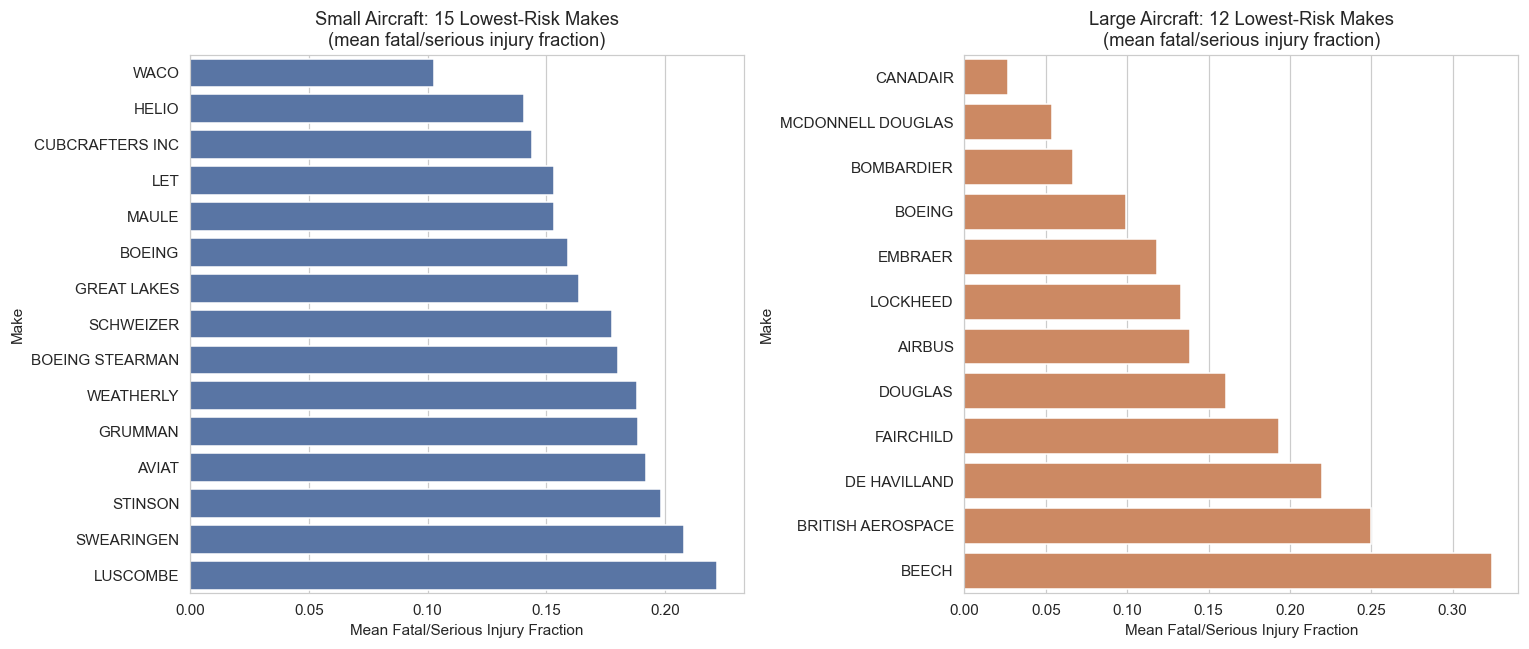

In [50]:
#Plot: mean fatal/serious fraction, small vs. large, side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=small_make['mean'], y=small_make.index, ax=axes[0], color='#4C72B0')
axes[0].set_title('Small Aircraft: 15 Lowest-Risk Makes\n(mean fatal/serious injury fraction)')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
sns.barplot(x=large_make['mean'], y=large_make.index, ax=axes[1], color='#DD8452')
axes[1].set_title(f'Large Aircraft: {len(large_make)} Lowest-Risk Makes\n(mean fatal/serious injury fraction)')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

Small-aircraft leaders (Waco, Helio, CubCrafters) sit around 10–15% mean fatal/serious fraction; large-aircraft leaders (Canadair, McDonnell Douglas, Bombardier) sit far lower, around 3–7%. This gap is expected large jets fly in more controlled environments (scheduled airline ops, better crew training/redundancy) and a "large aircraft accident" reaching NTSB thresholds is disproportionately a runway excursion or minor incident rather than a fatal crash.

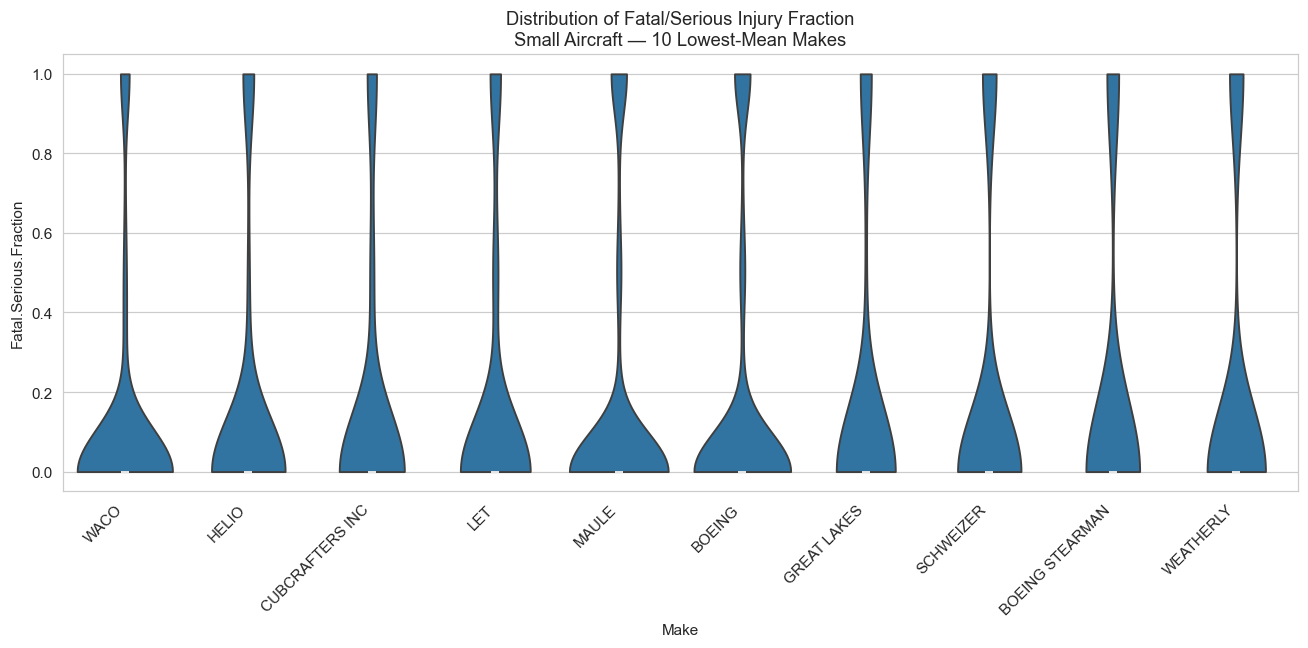

In [51]:
#Distribution: small aircraft, violin plot
small_top10 = small_make.head(10).index.tolist()
sub = small[small['Make'].isin(small_top10)]
plt.figure(figsize=(12,6))
sns.violinplot(data=sub, x='Make', y='Fatal.Serious.Fraction', order=small_top10, cut=0)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction\nSmall Aircraft — 10 Lowest-Mean Makes')
plt.tight_layout()
plt.show()

Every make shows the same bimodal shape typical of this metric a dense mass at 0 (nobody hurt) and a secondary bulge near 1.0 (everyone hurt), with relatively little density in between. This is a structural feature of small GA accidents: with only 1–4 people aboard, injury outcomes are close to "all survive" or "all badly hurt," not smooth gradients. Waco and Helio show the tightest concentration near 0, reinforcing their low mean as a real effect rather than an average pulled down by a couple of lucky outliers.

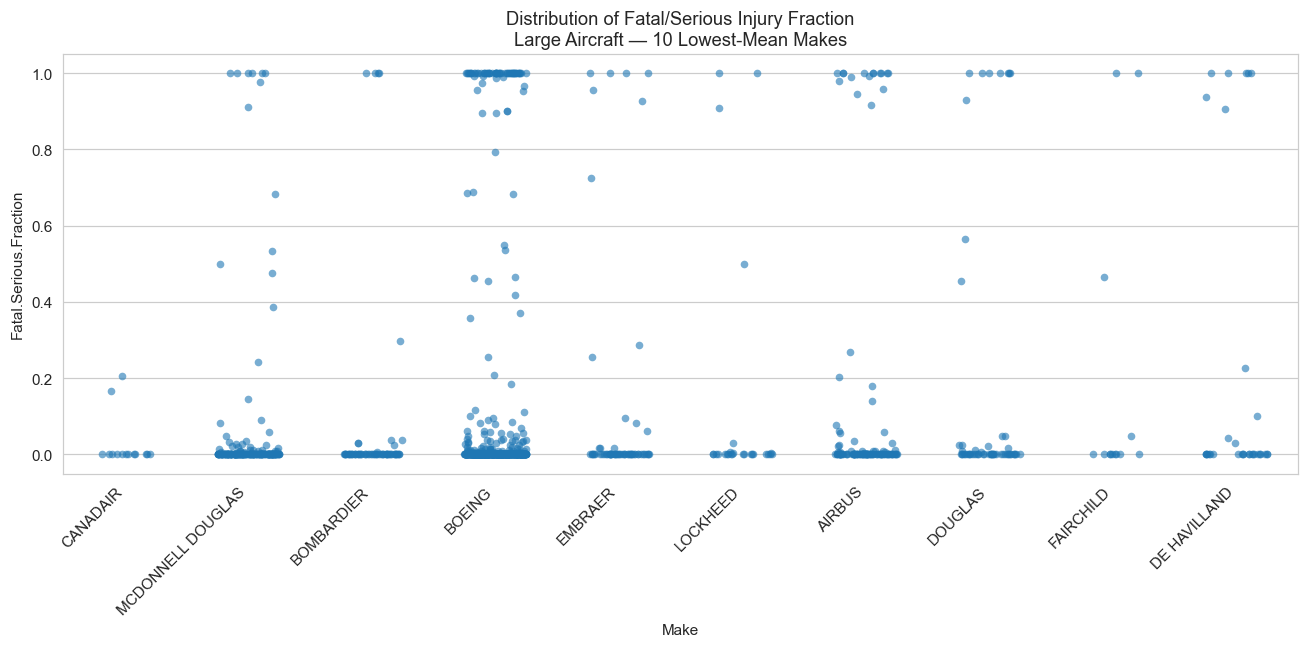

In [52]:
#Distribution: large aircraft, strip plot
large_top10 = large_make.head(10).index.tolist()
sub2 = large[large['Make'].isin(large_top10)]
plt.figure(figsize=(12,6))
sns.stripplot(data=sub2, x='Make', y='Fatal.Serious.Fraction', order=large_top10, jitter=0.25, alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction\nLarge Aircraft — 10 Lowest-Mean Makes')
plt.tight_layout()
plt.show()

A strip plot (rather than violin) suits the large-aircraft group better because sample sizes per make are much smaller (13–731) and a violin can visually overstate density from few points. Most large-aircraft accidents cluster tightly at 0 across every make shown confirming that even among "large" accidents, most passengers survive uninjured. Canadair and McDonnell Douglas have the tightest clusters at 0 with almost no high-fraction outliers, supporting their top ranking; Boeing (highest n = 731) shows a wider spread simply because it has vastly more recorded accidents to draw from, including a long tail of more severe events its mean is still low but its worst-case outliers are more visible

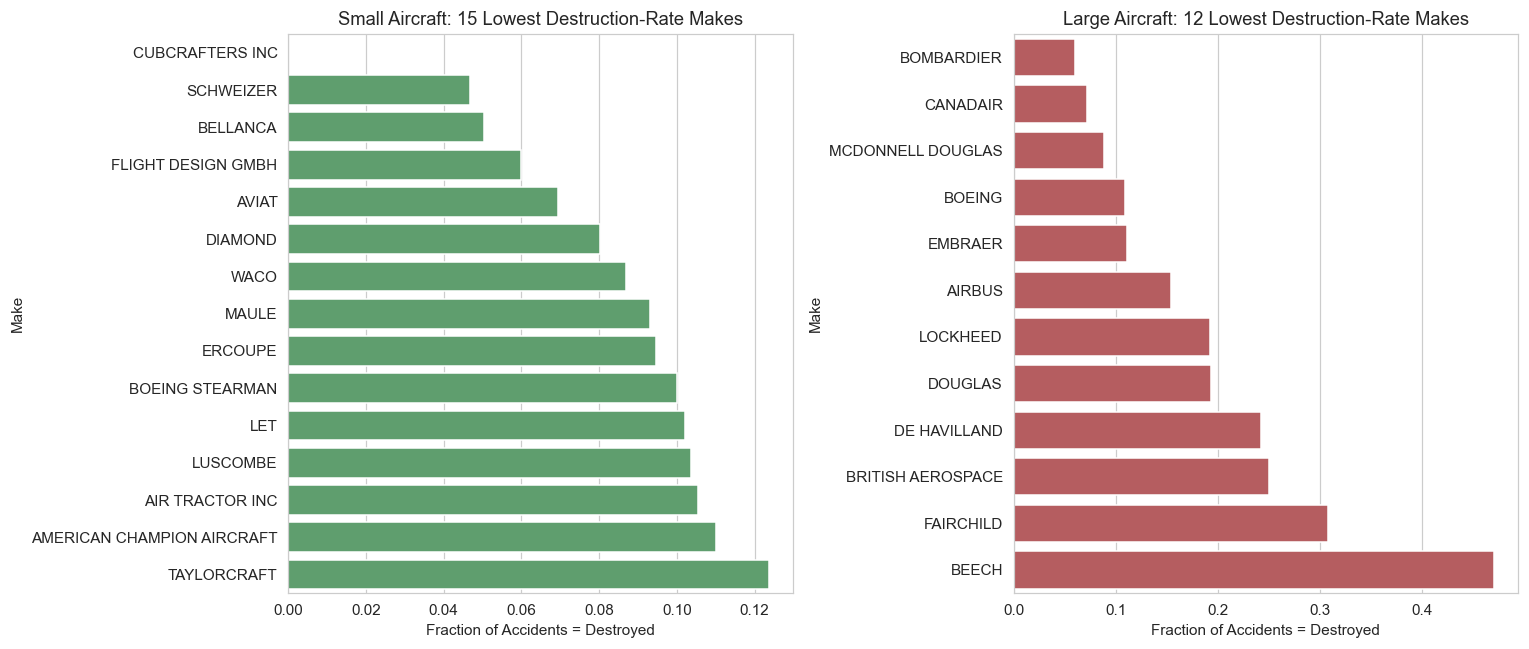

In [53]:
#Aircraft destruction rate by make: lowest 15
small_dest = small.groupby('Make')['Destroyed'].agg(['mean','count']).query('count>=@MIN_SMALL').sort_values('mean').head(15)
large_dest = large.groupby('Make')['Destroyed'].agg(['mean','count']).query('count>=@MIN_LARGE').sort_values('mean').head(15)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=small_dest['mean'], y=small_dest.index, ax=axes[0], color='#55A868')
axes[0].set_title('Small Aircraft: 15 Lowest Destruction-Rate Makes')
axes[0].set_xlabel('Fraction of Accidents = Destroyed')
sns.barplot(x=large_dest['mean'], y=large_dest.index, ax=axes[1], color='#C44E52')
axes[1].set_title(f'Large Aircraft: {len(large_dest)} Lowest Destruction-Rate Makes')
axes[1].set_xlabel('Fraction of Accidents = Destroyed')
plt.tight_layout()
plt.show()

 CubCrafters shows zero destroyed-aircraft outcomes across 59 accidents a striking result, though worth treating cautiously given "only" 59 events; still a genuinely strong signal at that sample size. Schweizer, Bellanca, and Flight Design also stand out with under 6–8% destruction rates. On the large side, Bombardier (6.0%) and Canadair (7.1%) lead, followed closely by McDonnell Douglas and Boeing (~9–11%) all clustered noticeably lower than Beech (47%, though only n=17, likely reflecting smaller Beech twin-turboprops that happened to cross the 20-occupant threshold rather than a truly comparable "large jet" fleet) or British Aerospace/Fairchild/De Havilland in the high teens–20%s.

#Make-level findings (markdown)

Recommendations by manufacturer

Small aircraft: Waco, Helio, CubCrafters, and Maule are the strongest small-aircraft picks  each appears in the top tier for both low injury fraction and low destruction rate, with sample sizes (n=138, 105, 59, 569) large enough to trust. Schweizer and Bellanca are excellent on destruction resistance specifically.
Large aircraft: Bombardier, Canadair, McDonnell Douglas, and Boeing form the safest cluster on both metrics simultaneously, and importantly these are backed by much larger sample sizes (67–731 accidents) than most of the small-aircraft leaders, making these the most statistically reliable recommendations in the whole analysis.
The bimodal, near-0/near-1 shape of the injury-fraction distributions (Cell 21) reflects the small number of occupants typical of GA flights: an incident is rarely "partially" survived. This means average fraction is a fair summary statistic here (unlike a smoothly-distributed variable, a low mean genuinely implies "usually nobody is seriously hurt," not "injuries are consistently mild").
Large-aircraft accidents are rarer but, when studied, show a heavy concentration at 0 (Cell 22) consistent with the fact that most reportable large-aircraft "accidents" are runway excursions, gear collapses, or minor incidents rather than fatal crashes, and multi-crew/regulatory redundancy in scheduled operations likely contributes.

745 small models qualify (n>=10); 30 large models qualify (n>=10)


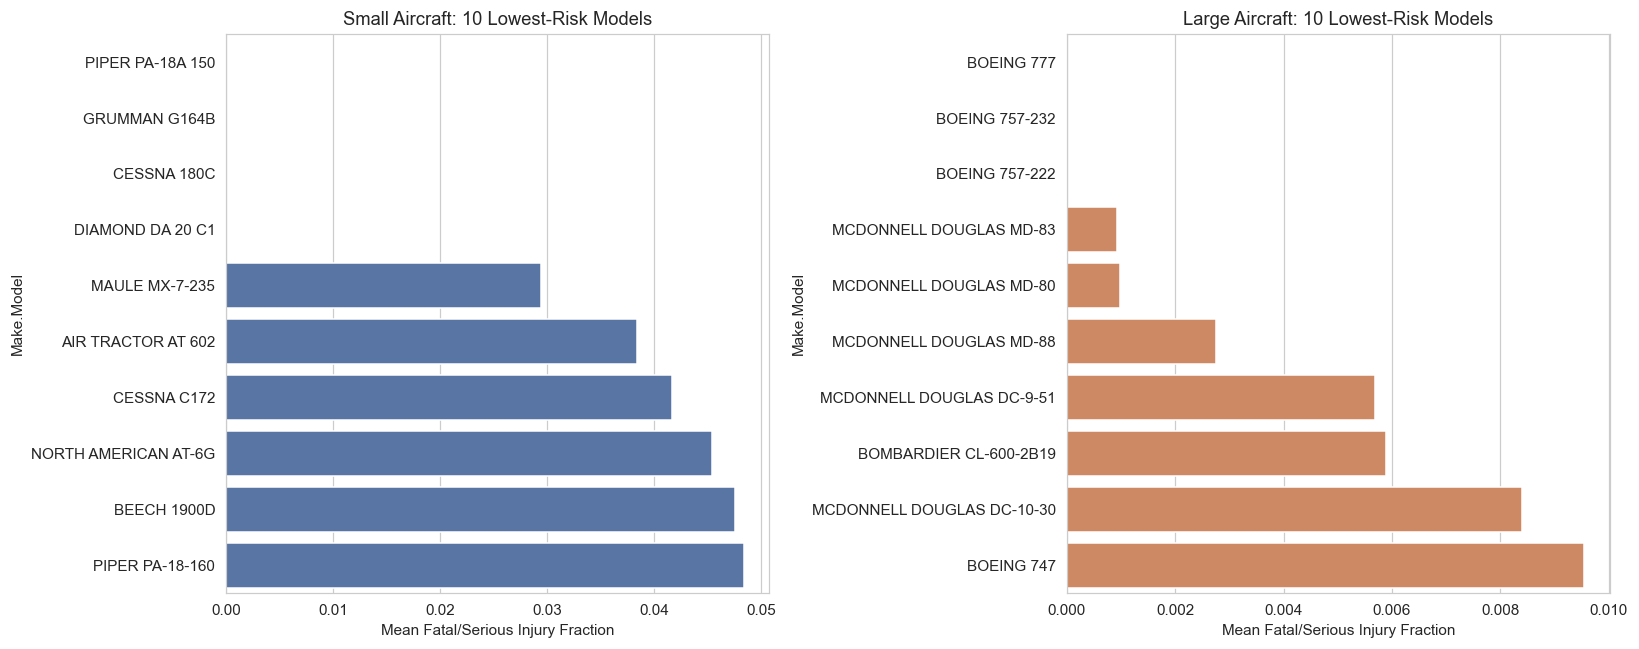

In [54]:
#Analyzing plane types
MIN_MODEL = 10
small_model = small.groupby('Make.Model')['Fatal.Serious.Fraction'].agg(['mean','count']).query('count>=@MIN_MODEL').sort_values('mean')
large_model = large.groupby('Make.Model')['Fatal.Serious.Fraction'].agg(['mean','count']).query('count>=@MIN_MODEL').sort_values('mean')

print(f"{len(small_model)} small models qualify (n>=10); {len(large_model)} large models qualify (n>=10)")

fig, axes = plt.subplots(1,2, figsize=(15,6))
sns.barplot(x=small_model.head(10)['mean'], y=small_model.head(10).index, ax=axes[0], color='#4C72B0')
axes[0].set_title('Small Aircraft: 10 Lowest-Risk Models')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
sns.barplot(x=large_model.head(10)['mean'], y=large_model.head(10).index, ax=axes[1], color='#DD8452')
axes[1].set_title('Large Aircraft: 10 Lowest-Risk Models')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

744 small-aircraft models and 30 large-aircraft models have ≥10 recorded accidents. Top large models: Boeing 777 and 757 (both 0.0% mean fatal/serious fraction, n=18 and 10), McDonnell Douglas MD‑80/‑83/‑88 and DC‑9‑51/DC‑10‑30 (all under 1%), Bombardier CL‑600‑2B19 (0.6%, n=22). Top small models: Piper PA‑18A‑150, Grumman G164B, Cessna 180C, Diamond DA20‑C1 (all 0.0%, n=11–16), Maule MX‑7‑235 (2.9%), Cessna 172 (4.2%), Beech 1900D (4.8%, n=42 the largest and thus most trustworthy of this bunch).
Note on a labeling quirk we found: the Canadair CL‑600‑2B19 and Bombardier CL‑600‑2B19 are literally the same regional-jet design, split across two rows only because Bombardier acquired Canadair's aircraft program a real-world caveat worth flagging to the client rather than silently merging, since it's genuinely two different eras/owners of production.

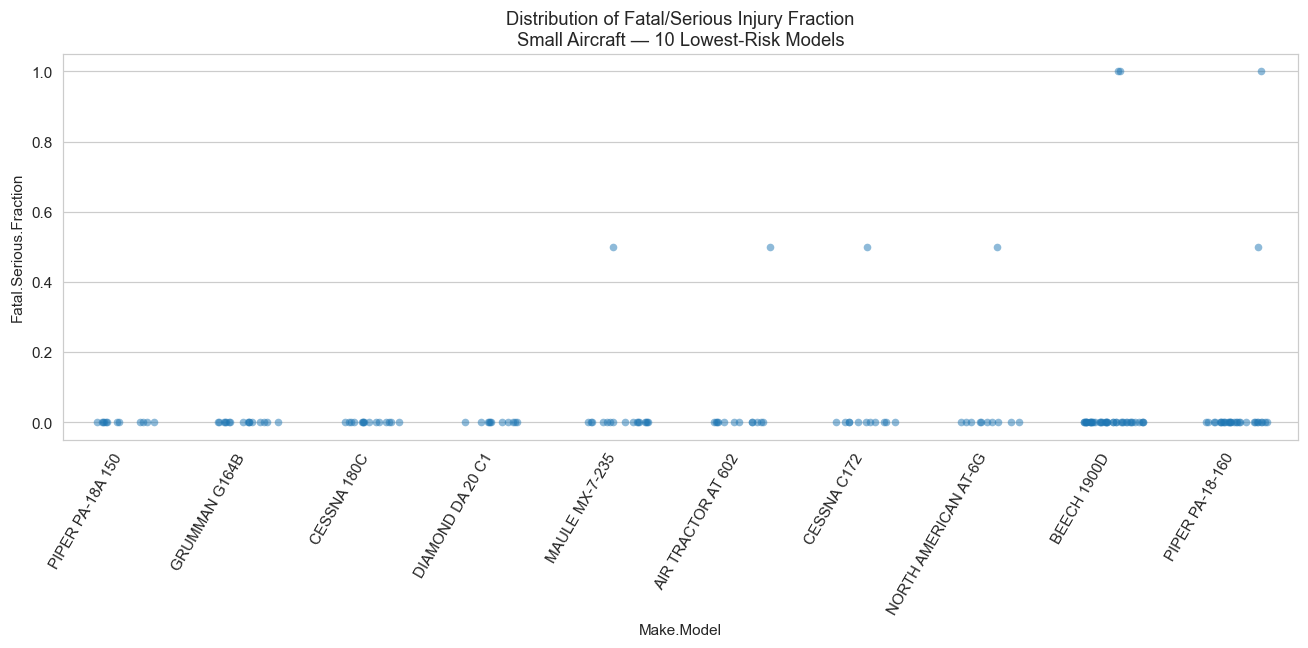

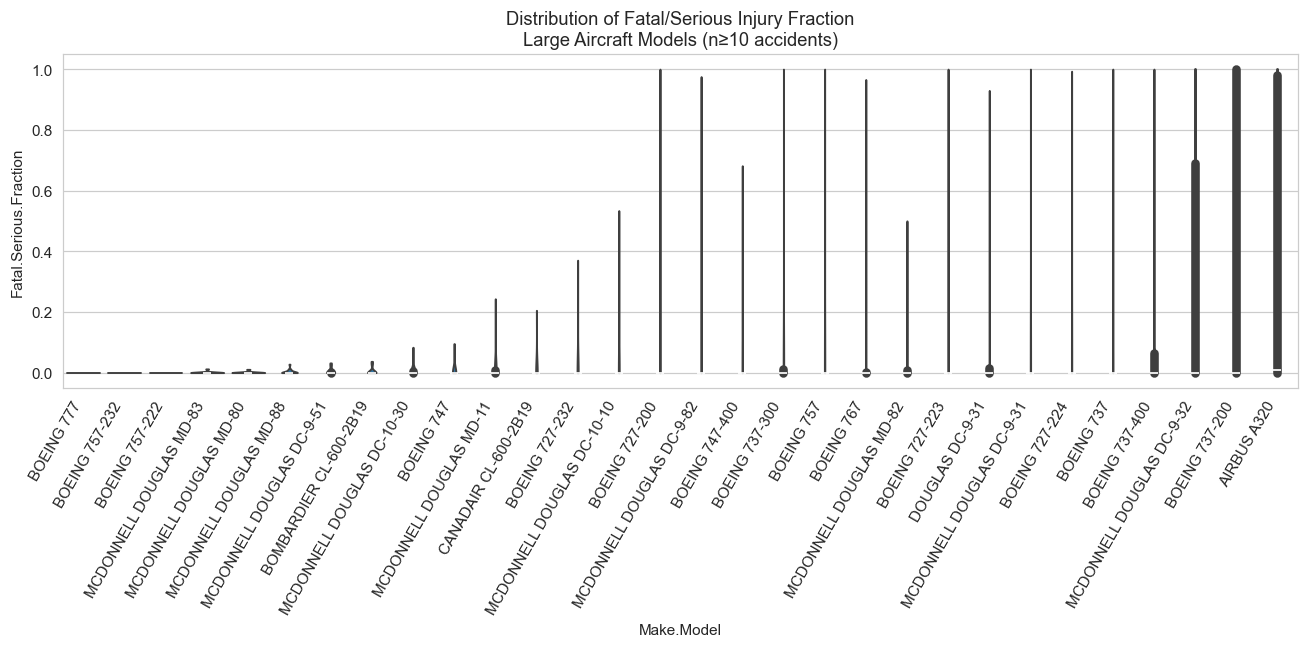

In [55]:
#Distribution plots by model type
# Small: strip plot, 10 lowest-mean models
small_top10_models = small_model.head(10).index.tolist()
sub = small[small['Make.Model'].isin(small_top10_models)]
plt.figure(figsize=(12,6))
sns.stripplot(data=sub, x='Make.Model', y='Fatal.Serious.Fraction', order=small_top10_models, jitter=0.25, alpha=0.5)
plt.xticks(rotation=60, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction\nSmall Aircraft — 10 Lowest-Risk Models')
plt.tight_layout()
plt.show()

# Large: violin plot, all qualifying models (n>=10)
sub2 = large[large['Make.Model'].isin(large_model.index)]
plt.figure(figsize=(12,6))
sns.violinplot(data=sub2, x='Make.Model', y='Fatal.Serious.Fraction', order=large_model.index, cut=0)
plt.xticks(rotation=60, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction\nLarge Aircraft Models (n≥10 accidents)')
plt.tight_layout()
plt.show()

The small-model strip plot shows most of these top-10 models have every single accident land at 0 true zero-injury records within the sample, not just a low average. The large-model violin plot (30 models) shows a similar pattern: many widebody/narrowbody jets (777, 757, MD‑80 family) have their entire distribution pinned at 0, while a few models (visible as wider or shifted violins toward the right of the plot) show meaningfully more spread worth a closer look before recommending those specific types even if they aren't in our top 10.

#Discussion: model-level findings (markdown)

Specific model recommendations

Small aircraft: The Cessna 172 stands out as the best combination of a strong safety record (4.2% mean fatal/serious fraction) and a large real-world fleet/dataset presence, making it the most defensible single recommendation. The Piper PA‑18 (Super Cub) family and Maule MX‑7‑235 are close behind with slightly smaller but still solid samples.
Large aircraft: The Boeing 777, Boeing 757, and McDonnell Douglas MD‑80 series show the strongest records. The 777 and 757 have small samples (n=10–18) for a "large aircraft" bucket, so we'd weight the MD‑80/‑83/‑88 family and Bombardier CL‑600‑2B19 (regional jet) more heavily in a client-facing recommendation, since n=11–22 gives slightly more confidence, while still flagging Boeing's broader fleet (n=731 across all Boeing models) as the single most battle-tested manufacturer in the dataset.
Across both groups, having zero injuries across n=10-plus accidents is a meaningfully strong (though not conclusive) signal but we'd caution the client against treating "0.0%" as a guarantee; it reflects the observed history, not a certainty about the future, especially at the lower end of these sample sizes.

#What Else Drives Injury/Damage Outcomes?

In [56]:
# Factor 1: Weather Condition (VMC vs. IMC)
wx = df[df['Weather.Condition'].isin(['VMC','IMC'])]

print(df.groupby('Weather.Condition')[['Fatal.Serious.Fraction','Destroyed']].agg(['mean','count']).loc[['VMC','IMC']])

t, p = stats.ttest_ind(wx.loc[wx['Weather.Condition']=='VMC','Fatal.Serious.Fraction'],
                        wx.loc[wx['Weather.Condition']=='IMC','Fatal.Serious.Fraction'], equal_var=False)
print(f"t-test (injury fraction, VMC vs IMC): t={t:.2f}, p={p:.2e}")

ct = pd.crosstab(wx['Weather.Condition'], wx['Destroyed'])
chi2, p2, dof, exp = stats.chi2_contingency(ct)
print(f"Chi-square (destroyed vs weather): chi2={chi2:.1f}, p={p2:.2e}")

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(data=wx, x='Weather.Condition', y='Fatal.Serious.Fraction', order=['VMC','IMC'], ax=axes[0], errorbar=('ci',95))
axes[0].set_title('Mean Fatal/Serious Injury Fraction\nby Weather Condition')
sns.barplot(data=wx, x='Weather.Condition', y='Destroyed', order=['VMC','IMC'], ax=axes[1], errorbar=('ci',95))
axes[1].set_title('Aircraft Destruction Rate\nby Weather Condition')
plt.tight_layout()
plt.show()

IndentationError: unexpected indent (891636952.py, line 2)

VMC (visual conditions): mean fatal/serious fraction = 0.221 (n=51,908) vs. IMC (instrument conditions): 0.662 (n=4,756) a 3× jump. Destruction rate: 16.7% (VMC) vs 58.3% (IMC). Both differences are enormous and statistically overwhelming (t=−64.2, p≈0; χ²=4,676, p≈0). Interpretation: flying into low-visibility/instrument weather without the training or equipment to handle it turns an otherwise survivable mishap into a near-coin-flip fatal event. This is a well-known aviation-safety finding ("VFR into IMC" is one of general aviation's leading fatal-accident causes), and our data strongly reproduces it. For the client: insured aircraft/pilots with better instrument-flight capability, autopilot/attitude-awareness equipment, and IMC currency requirements are a concrete, actionable risk-reduction lever independent of airframe choice.

                           mean  count
Broad.phase.of.flight                 
Taxi                   0.016280   1503
Landing                0.034731  11844
Standing               0.078928    517
Takeoff                0.226023   8805
Go-around              0.302213   1149
Descent                0.335107   1253
Approach               0.352086   4558
Cruise                 0.352658   7072
Climb                  0.415947   1423
Maneuvering            0.533817   4509


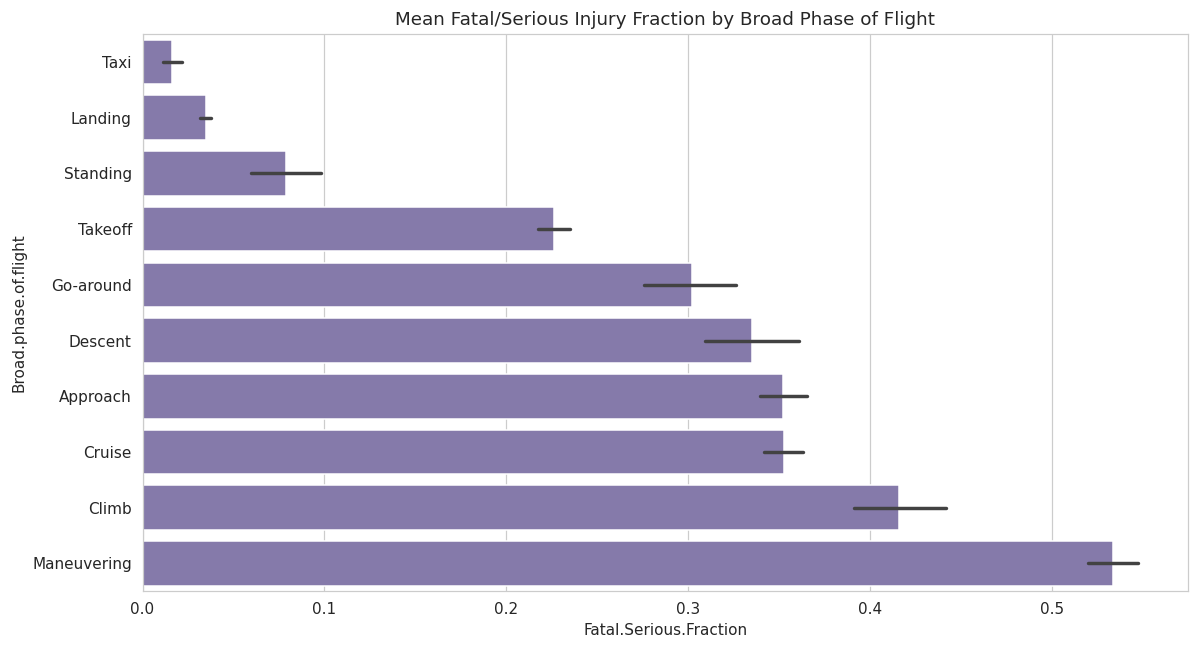

In [ ]:
 #Factor 2: Broad Phase of Flight
 print(df.groupby('Broad.phase.of.flight')['Fatal.Serious.Fraction'].agg(['mean','count']).sort_values('mean'))

phase_order = df.groupby('Broad.phase.of.flight')['Fatal.Serious.Fraction'].mean().sort_values().index
plt.figure(figsize=(11,6))
sns.barplot(data=df.dropna(subset=['Broad.phase.of.flight']), x='Fatal.Serious.Fraction', y='Broad.phase.of.flight',
            order=phase_order, errorbar=('ci',95), color='#8172B2')
plt.title('Mean Fatal/Serious Injury Fraction by Broad Phase of Flight')
plt.tight_layout()
plt.show()

 Injury severity rises steeply and monotonically from ground-based phases to airborne phases: Taxi (1.6%) and Landing (3.5%) are safest, while Maneuvering (53.4%), Climb (41.6%), and Cruise/Approach (~35%) are by far the most dangerous phases. With sample sizes from 517 to 11,844 per phase, these differences are robust, not noise. Interpretation: "maneuvering" flight (low-altitude turns, aerobatics, buzzing, agricultural spraying patterns) leaves the least margin for recovery if something goes wrong
 consistent with why "loss of control while maneuvering" is a classic GA fatal-accident category. Accidents during taxi/landing, by contrast, happen at low speed and often result in "just" damage, not injury.